This is the evaluation of [Getting Started Qwen2.5-32b-instruct-awq [infer]](https://www.kaggle.com/code/jiazhuang/getting-started-qwen2-5-32b-instruct-awq-infer)

In [1]:
import re
import json
import numpy as np
import pandas as pd

from tqdm.auto import tqdm
tqdm.pandas()

import kagglehub
from IPython.display import display, SVG, HTML

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
metric = kagglehub.package_import('jiazhuang/svg-image-fidelity')

Installing python dependencies for Package 'kagglehub_package_jiazhuang_svg_image_fidelity_10', logging progress to '/tmp/kagglehub-package-dependencies-install-n1aizgig.txt'.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

## Load Data

In [3]:
train_df = pd.read_json('/kaggle/input/getting-started-qwen2-5-32b-instruct-awq-infer/train_svg.jsonl', lines=True)

In [4]:
drawing_with_llms_path = kagglehub.competition_download('drawing-with-llms')
train_question_df = pd.read_parquet(f'{drawing_with_llms_path}/questions.parquet')

train_question_df = train_question_df.groupby('id').apply(lambda df: df.to_dict(orient='list'))
train_question_df = train_question_df.reset_index(name='qa')

train_question_df['question'] = train_question_df.qa.apply(lambda qa: json.dumps(qa['question'], ensure_ascii=False))

train_question_df['choices'] = train_question_df.qa.apply(
    lambda qa: json.dumps(
        [x.tolist() for x in qa['choices']], ensure_ascii=False
    )
)

train_question_df['answer'] = train_question_df.qa.apply(lambda qa: json.dumps(qa['answer'], ensure_ascii=False))

train_df = pd.merge(train_df, train_question_df, how='left', on='id')

<ipython-input-4-099796f0a2d4>:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_question_df = train_question_df.groupby('id').apply(lambda df: df.to_dict(orient='list'))


In [5]:
train_df['multiple_choice_qa'] = train_df.apply(
    lambda r: {
    'question': json.loads(r.question),
    'choices': json.loads(r.choices),
    'answer': json.loads(r.answer)
    },
    axis=1,
)

train_df.head()

,id,description,svg,qa,question,choices,answer,multiple_choice_qa
0,02d892,a purple forest at dusk,"<svg viewBox=""0 0 256 256"" width=""256"" height=...","{'id': ['02d892', '02d892', '02d892', '02d892'...","[""What is the main setting of the image?"", ""Is...","[[""beach"", ""desert"", ""forest"", ""mountain""], [""...","[""forest"", ""yes"", ""dusk"", ""purple""]",{'question': ['What is the main setting of the...
1,0dcd2e,gray wool coat with a faux fur collar,"<svg viewBox=""0 0 256 256"" width=""256"" height=...","{'id': ['0dcd2e', '0dcd2e', '0dcd2e', '0dcd2e'...","[""What color is the coat?"", ""What part of the ...","[[""blue"", ""brown"", ""gray"", ""red""], [""collar"", ...","[""gray"", ""collar"", ""no"", ""wool""]","{'question': ['What color is the coat?', 'What..."
2,1e9ac1,a lighthouse overlooking the ocean,"<svg viewBox=""0 0 256 256"" width=""256"" height=...","{'id': ['1e9ac1', '1e9ac1', '1e9ac1', '1e9ac1'...","[""Is there an ocean visible in the image?"", ""W...","[[""no"", ""yes""], [""inside"", ""next to"", ""overloo...","[""yes"", ""overlooking"", ""no"", ""no""]",{'question': ['Is there an ocean visible in th...
3,2b25db,burgundy corduroy pants with patch pockets and...,"<svg viewBox=""0 0 256 256"" width=""256"" height=...","{'id': ['2b25db', '2b25db', '2b25db', '2b25db'...","[""Are the pants yellow?"", ""Do the pants have p...","[[""no"", ""yes""], [""no"", ""yes""], [""no"", ""yes""], ...","[""no"", ""yes"", ""yes"", ""pants""]","{'question': ['Are the pants yellow?', 'Do the..."
4,4e6a54,orange corduroy overalls,"<svg viewBox=""0 0 256 256"" width=""256"" height=...","{'id': ['4e6a54', '4e6a54', '4e6a54', '4e6a54'...","[""What material is the item?"", ""Is a hat depic...","[[""corduroy"", ""denim"", ""leather"", ""silk""], [""n...","[""corduroy"", ""no"", ""yes"", ""overalls""]","{'question': ['What material is the item?', 'I..."


## Calc Metric

In [6]:
train_df['score'] = train_df.progress_apply(
    lambda r: metric.score_instance(r.multiple_choice_qa, r.svg),
    axis=1,
)

  0%|          | 0/15 [00:00<?, ?it/s]

The 'batch_size' argument of HybridCache is deprecated and will be removed in v4.49. Use the more precisely named 'max_batch_size' argument instead.
The 'batch_size' attribute of HybridCache is deprecated and will be removed in v4.49. Use the more precisely named 'self.max_batch_size' attribute instead.


In [7]:
pd.DataFrame(train_df.score.tolist()).mean()

competition_score    0.559704
vqa_score            0.662914
ocr_score            0.957859
aesthetic_score      0.408519
dtype: float64

## Display

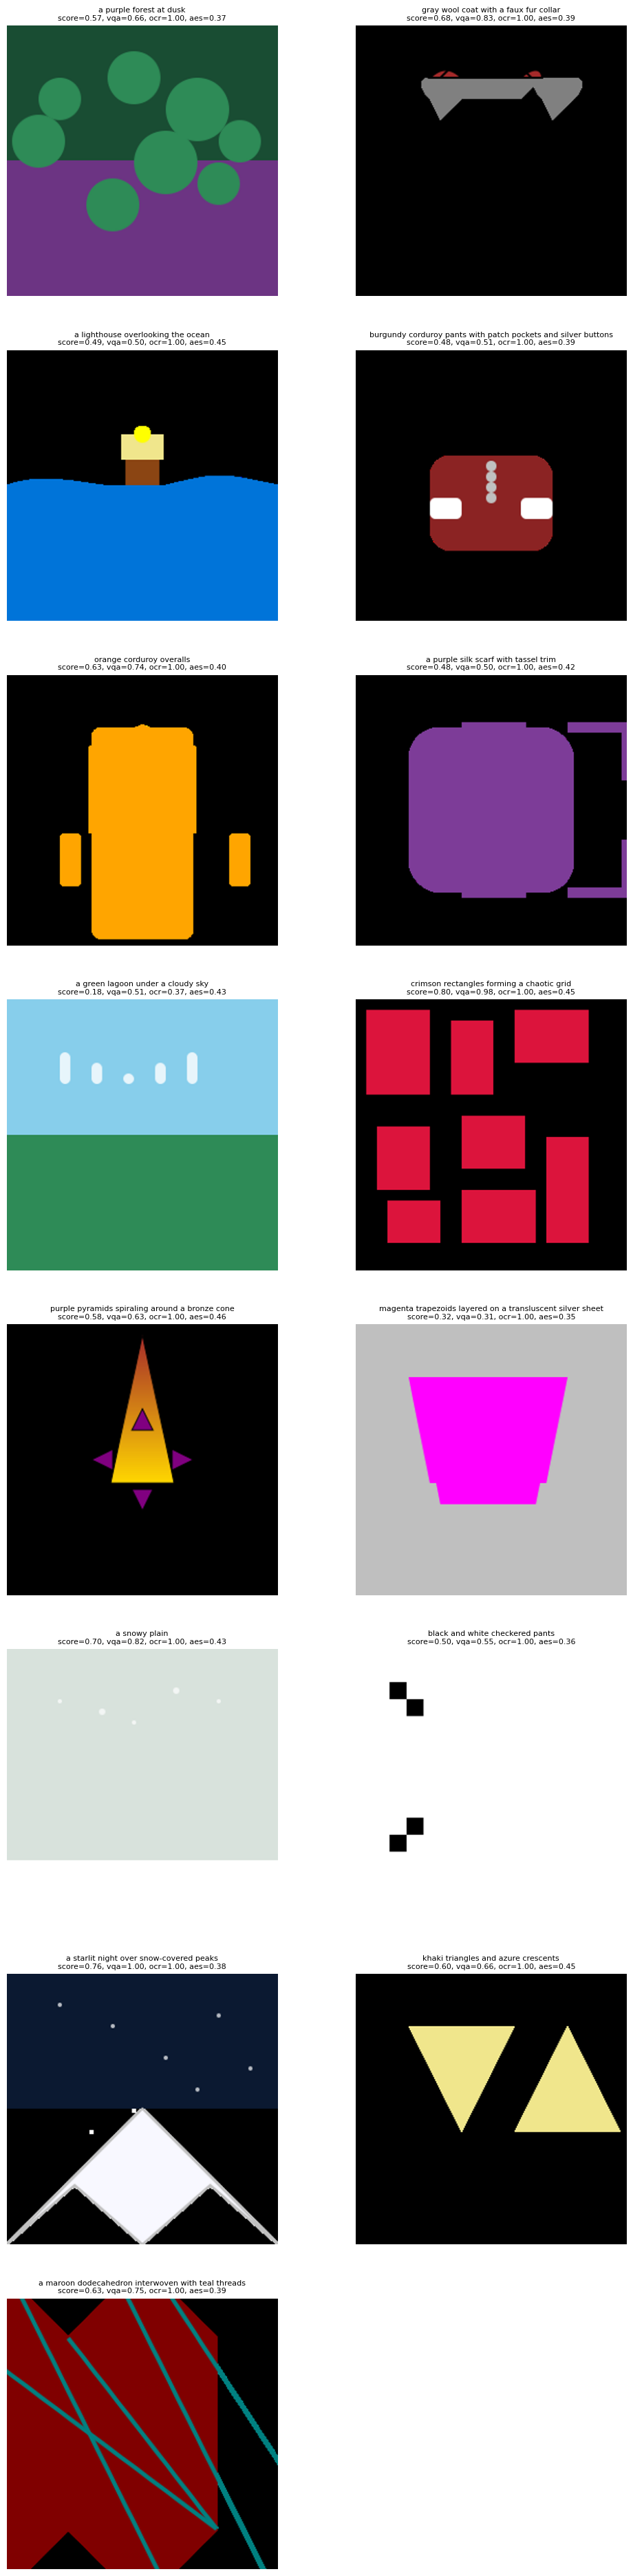

In [8]:
plt.figure(figsize=(12, 48))
for i, r in enumerate(train_df.itertuples(), 1):
    score = r.score['competition_score']
    vqa = r.score['vqa_score']
    ocr = r.score['ocr_score']
    aes = r.score['aesthetic_score']
    
    plt.subplot(8, 2, i)
    img = metric.svg_to_png(r.svg)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'{r.description}\nscore={score:.2f}, vqa={vqa:.2f}, ocr={ocr:.2f}, aes={aes:.2f}', fontdict={'fontsize': 8})